# Procesador de archivos  `postprocesing\U` OpenFOAM V12.00
----------------------------------------------------------
Alumno: Omar Ulises Robles Pereyra

Catedrático: Dr. Gabriel Ruiz Martínez

**Subcoordinación de Posgrado y Educación Continua.**

![Imagen](IMTA_Logo.jpg)

[Instituto Mexicano de Tecnología del Agua](https://www.gob.mx/imta).


Este script utiliza la librería Pandas para leer y procesar datos de un archivo de texto generado por una simulación de OpenFOAM. El objetivo principal es extraer la información de la evolución de la presión a lo largo del tiempo para diferentes puntos (probes) ubicados en el dominio de la simulación. El código solicita al usuario el número de probes presentes en el archivo y el nombre del archivo a procesar. Luego, lee los datos, identifica la columna de tiempo y las columnas correspondientes a cada probe, y finalmente genera un gráfico que muestra la variación de la presión en función del tiempo para una probe específica, utilizando los índices de las columnas del DataFrame de Pandas.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

**Entrada de Usuario**

In [19]:
total_probes = 7
#total_probes = 95

Realizando la lectura del archivo

In [20]:
data_start = total_probes
# Carga de archivo postproceso
file = 'p_test.txt'
#file = 'p_test_long.txt'
print(file)

p_test.txt


In [28]:
# Leer el archivo, saltando las líneas de información  de los probes
df = pd.read_csv(file, skiprows=data_start, sep=r'\s+',comment='#',header=None)
print(df)

              0          1          2          3          4         5  \
0      0.000000   0.000000   0.000000   0.000000   0.000000  0.000000   
1      0.000120 -91.428237 -39.436769 -22.194142 -13.454010 -6.510940   
2      0.000264   6.302248   2.341588   1.072523   0.476887  0.071195   
3      0.000437  20.111403   6.791462   4.422724   3.017925  1.723471   
4      0.000644   1.329228   0.950460   0.399213   0.203286  0.079926   
...         ...        ...        ...        ...        ...       ...   
6366   9.995238  -0.281007  -0.378514  -0.344075  -0.092028 -0.053548   
6367   9.996429  -0.282311  -0.376072  -0.346715  -0.092961 -0.053563   
6368   9.997619  -0.283804  -0.373550  -0.349413  -0.094036 -0.053753   
6369   9.998810  -0.285617  -0.371164  -0.352062  -0.095114 -0.053858   
6370  10.000000  -0.287585  -0.368387  -0.354699  -0.096221 -0.054044   

             6         7  
0     0.000000  0.000000  
1    -1.028368 -0.094577  
2    -0.079711 -0.018315  
3     0.400261 

In [30]:
column_names = {'0': 'Time'}
column_names.update({i + 1: f'Probe_{i}' for i in range(total_probes + 1)})
df = df.rename(columns=column_names)
print(df)

              0    Probe_0    Probe_1    Probe_2    Probe_3   Probe_4  \
0      0.000000   0.000000   0.000000   0.000000   0.000000  0.000000   
1      0.000120 -91.428237 -39.436769 -22.194142 -13.454010 -6.510940   
2      0.000264   6.302248   2.341588   1.072523   0.476887  0.071195   
3      0.000437  20.111403   6.791462   4.422724   3.017925  1.723471   
4      0.000644   1.329228   0.950460   0.399213   0.203286  0.079926   
...         ...        ...        ...        ...        ...       ...   
6366   9.995238  -0.281007  -0.378514  -0.344075  -0.092028 -0.053548   
6367   9.996429  -0.282311  -0.376072  -0.346715  -0.092961 -0.053563   
6368   9.997619  -0.283804  -0.373550  -0.349413  -0.094036 -0.053753   
6369   9.998810  -0.285617  -0.371164  -0.352062  -0.095114 -0.053858   
6370  10.000000  -0.287585  -0.368387  -0.354699  -0.096221 -0.054044   

       Probe_5   Probe_6  
0     0.000000  0.000000  
1    -1.028368 -0.094577  
2    -0.079711 -0.018315  
3     0.400261 

In [23]:
# Graficar la evolución de la presión en el tiempo de cada probe
time = df[0]
print(time)

0        0.000000
1        0.000120
2        0.000264
3        0.000437
4        0.000644
          ...    
6366     9.995238
6367     9.996429
6368     9.997619
6369     9.998810
6370    10.000000
Name: 0, Length: 6371, dtype: float64


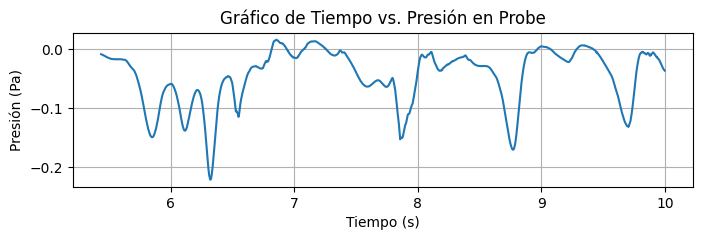

In [24]:
plt.figure(figsize=(8,2))
plt.plot(df.iloc[3000:-1,0], df.iloc[3000:-1,6])
plt.xlabel('Tiempo (s)')
plt.ylabel('Presión (Pa)')  # Asumiendo que la columna 1 es Probe 0
plt.title('Gráfico de Tiempo vs. Presión en Probe')
plt.grid(True)
plt.show()